# Marine heatwaves across the Palau EEZ

```{glue:figure} mhw_eez_all
:scale: 70%
:align: center
```

**Figure. Marine heatwaves for the Palau Exclusive Economic Zone (EEZ).** Daily SST is spatially averaged over ocean grid cells whose centres fall inside the EEZ, then compared with the seasonal climatology and 90th-percentile threshold. A configurable point analysis follows the EEZ-wide estimate.

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapefile
import xarray as xr
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath
from shapely.geometry import Point, shape
from shapely.ops import unary_union
from shapely.prepared import prep

try:
    from myst_nb import glue
except ImportError:
    def glue(name, value, display=False):
        return value

style = "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "seaborn-whitegrid"
plt.style.use(style)
LEGEND_FONTSIZE = 12
AXIS_LABEL_FONTSIZE = 14
TICK_LABEL_FONTSIZE = 12
TITLE_FONTSIZE = 14
plt.rcParams.update({
    "legend.fontsize": LEGEND_FONTSIZE,
    "axes.labelsize": AXIS_LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_LABEL_FONTSIZE,
    "ytick.labelsize": TICK_LABEL_FONTSIZE,
})

## Method

A marine heatwave (MHW) occurs when daily SST exceeds a seasonally varying 90th-percentile threshold for at least five consecutive days (Hobday et al., 2016). Events separated by gaps of two days or fewer are joined. Categories I–IV follow Hobday et al. (2018).

The primary analysis uses the area-weighted daily mean of all OISST grid cells whose centres lie inside the Palau EEZ. This is an **EEZ-wide index**, not a statement that every location is simultaneously experiencing a MHW. The second analysis lets the user select a single location.

Calculations use Eric C. J. Oliver's [`marineHeatWaves`](https://github.com/ecjoliver/marineHeatWaves) implementation (`detect`, `blockAverage`, and `meanTrend`), downloaded from commit [`d7292bf`](https://github.com/ecjoliver/marineHeatWaves/tree/d7292bf08ade0af213fa760b0d7e4adfe5f52894). The local copy includes only the `np.NaN` → `np.nan` compatibility change required by NumPy 2.

### References

- Hobday, A. J. et al. (2016). *A hierarchical approach to defining marine heatwaves*. Progress in Oceanography, 141, 227–238. [https://doi.org/10.1016/j.pocean.2015.12.014](https://doi.org/10.1016/j.pocean.2015.12.014)
- Hobday, A. J. et al. (2018). *Categorizing and naming marine heatwaves*. Oceanography, 31(2), 162–173. [https://doi.org/10.5670/oceanog.2018.205](https://doi.org/10.5670/oceanog.2018.205)
- Oliver, E. C. J. (2015–). *marineHeatWaves: Marine heatwave detection code*. [https://github.com/ecjoliver/marineHeatWaves](https://github.com/ecjoliver/marineHeatWaves)

## Setup

In [3]:
candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in candidates if (p / "functions/marineHeatWaves.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the CIndRA project root.")

sys.path.insert(0, str(PROJECT_ROOT / "functions"))
import marineHeatWaves as mhw

path_data = PROJECT_ROOT / "data/sea_surface_temperature/sst_daily_1981_2024_palau.nc"
path_eez = PROJECT_ROOT / "data/Palau_EEZ/pw_eez_pol_april2022.shp"
path_figs = PROJECT_ROOT / "notebooks/matrix_cc/figures"
path_figs.mkdir(parents=True, exist_ok=True)

climatology_period = [1983, 2012]
analysis_end = "2024-12-31"

# Point-analysis option: edit these coordinates and rerun from this cell downward.
user_lon = 134.368203
user_lat = 7.322074

## Shared analysis functions

These functions apply identical preprocessing, detection, tabulation and annual aggregation to the EEZ-average and point series.

In [4]:
category_names = {1: "I Moderate", 2: "II Strong", 3: "III Severe", 4: "IV Extreme"}
category_colors = {1: "#f9d057", 2: "#f29e2e", 3: "#e76818", 4: "#9d182f"}
category_code = {"Moderate": 1, "Strong": 2, "Severe": 3, "Extreme": 4}

def prepare_series(data_array):
    units = str(data_array.attrs.get("units", "")).lower()
    values = data_array.load()
    if units in {"k", "kelvin", "degrees_kelvin"} or float(values.median(skipna=True)) > 100:
        values = values - 273.15
    series = values.to_series()
    series.index = pd.to_datetime(series.index)
    series = series.groupby(level=0).mean().sort_index().loc[:analysis_end]
    return series.reindex(pd.date_range(series.index.min(), series.index.max(), freq="D")).astype(float)

def detect_events(series):
    t = np.array([timestamp.date().toordinal() for timestamp in series.index])
    events, clim = mhw.detect(
        t, series.to_numpy(), climatologyPeriod=climatology_period,
        pctile=90, windowHalfWidth=5, smoothPercentile=True,
        smoothPercentileWidth=31, minDuration=5, joinAcrossGaps=True,
        maxGap=2, maxPadLength=2,
    )
    return t, events, clim

def event_dataframe(events):
    table = pd.DataFrame({
        "start": pd.to_datetime(events["date_start"]),
        "end": pd.to_datetime(events["date_end"]),
        "peak": pd.to_datetime(events["date_peak"]),
        "duration_days": events["duration"],
        "max_intensity_degC": events["intensity_max"],
        "mean_intensity_degC": events["intensity_mean"],
        "cumulative_intensity_degC_days": events["intensity_cumulative"],
        "category": events["category"],
    })
    table.index.name = "event"
    return table

def annual_indicators(t, series, events, clim):
    raw = mhw.blockAverage(t, events, clim=clim, temp=series.to_numpy())
    annual = pd.DataFrame({
        "year": raw["years_start"].astype(int), "event_count": raw["count"],
        "mhw_days": raw["total_days"], "mean_duration_days": raw["duration"],
        "mean_max_intensity_degC": raw["intensity_max"],
        "cumulative_intensity_degC_days": raw["intensity_cumulative"],
    })
    complete = annual["year"].between(series.index.min().year + 1, series.index.max().year - 1)
    annual = annual.loc[complete].reset_index(drop=True)
    trend_raw = {key: np.asarray(value)[complete.to_numpy()] for key, value in raw.items()}
    means, trends, ci = mhw.meanTrend(trend_raw)
    keys = ["count", "total_days", "duration", "intensity_max", "intensity_cumulative"]
    trend_table = pd.DataFrame({
        "indicator": ["Event count", "MHW days", "Mean duration", "Mean maximum intensity", "Cumulative intensity"],
        "mean": [means[k] for k in keys],
        "trend_per_decade": [10 * trends[k] for k in keys],
        "ci95_per_decade": [10 * ci[k] for k in keys],
    })
    return annual, trend_table

def plot_mhw_timeline(series, events, clim, title, start=None, end=None, figsize=(17, 5)):
    mask = pd.Series(True, index=series.index)
    if start is not None: mask &= series.index >= pd.Timestamp(start)
    if end is not None: mask &= series.index <= pd.Timestamp(end)
    idx = np.flatnonzero(mask.to_numpy())
    if idx.size == 0: raise ValueError("The requested plotting period contains no observations.")
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(series.index[idx], series.iloc[idx], color="0.35", lw=0.65, label="Daily SST")
    ax.plot(series.index[idx], np.asarray(clim["seas"])[idx], color="#2878b5", lw=1.2, label="Seasonal climatology")
    ax.plot(series.index[idx], np.asarray(clim["thresh"])[idx], color="#d73027", lw=1.1, label="90th-percentile threshold")
    for i in range(events["n_events"]):
        event_idx = np.arange(events["index_start"][i], events["index_end"][i] + 1)
        event_idx = event_idx[np.isin(event_idx, idx)]
        if event_idx.size:
            raw = events["category"][i]
            cat = category_code.get(str(raw), int(raw) if str(raw).isdigit() else 1)
            ax.fill_between(series.index[event_idx], np.asarray(clim["seas"])[event_idx],
                            series.iloc[event_idx], color=category_colors[cat], alpha=0.7, linewidth=0)
    handles, _ = ax.get_legend_handles_labels()
    handles += [Patch(facecolor=category_colors[k], label=category_names[k]) for k in category_names]
    ax.legend(handles=handles, ncol=4, loc="upper left", fontsize=LEGEND_FONTSIZE)
    ax.set(ylabel="SST (°C)", title=title)
    ax.set_xlim(series.index[idx[0]], series.index[idx[-1]])
    ax.margins(x=0)
    fig.tight_layout()
    return fig, ax

## 1. EEZ-wide analysis

### Build and inspect the EEZ mask

The shapefile polygons are dissolved into one geometry. A grid cell is included when its centre is covered by that geometry. The EEZ mean uses cosine-of-latitude area weights and ignores land/missing cells independently each day.

In [5]:
ds = xr.open_dataset(path_data)
reader = shapefile.Reader(str(path_eez))
eez_geometry = unary_union([shape(item.__geo_interface__) for item in reader.shapes()])
prepared_eez = prep(eez_geometry)

lon2d, lat2d = np.meshgrid(ds.lon.values, ds.lat.values)
inside = np.array([prepared_eez.covers(Point(x, y)) for x, y in zip(lon2d.ravel(), lat2d.ravel())])
eez_mask = xr.DataArray(inside.reshape(lon2d.shape), coords={"lat": ds.lat, "lon": ds.lon}, dims=("lat", "lon"))
valid_ocean = ds["sst"].notnull().any("time")
eez_ocean_mask = eez_mask & valid_ocean

if not bool(eez_ocean_mask.any()):
    raise ValueError("No OISST grid-cell centres fall inside the Palau EEZ.")

weights = np.cos(np.deg2rad(ds.lat)).broadcast_like(ds["sst"].isel(time=0))
sst_eez = ds["sst"].where(eez_ocean_mask).weighted(weights.where(eez_ocean_mask, 0)).mean(("lat", "lon"))
series_eez = prepare_series(sst_eez)

print(f"EEZ ocean grid cells: {int(eez_ocean_mask.sum())}")
print(f"Period: {series_eez.index.min().date()} to {series_eez.index.max().date()}")
print(f"Missing daily EEZ means: {series_eez.isna().sum()} ({series_eez.isna().mean():.2%})")

EEZ ocean grid cells: 806
Period: 1981-09-01 to 2024-08-24
Missing daily EEZ means: 0 (0.00%)


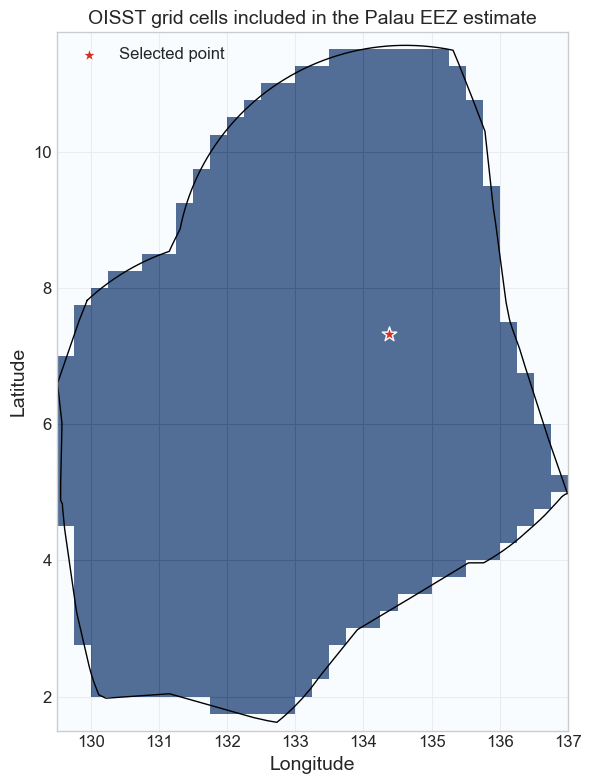

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pcolormesh(ds.lon, ds.lat, eez_ocean_mask, cmap="Blues", shading="nearest", alpha=0.7)
for polygon in ([eez_geometry] if eez_geometry.geom_type == "Polygon" else eez_geometry.geoms):
    x, y = polygon.exterior.xy
    ax.plot(x, y, color="black", lw=1)
ax.scatter(user_lon, user_lat, marker="*", s=120, color="#d73027", edgecolor="white", label="Selected point")
ax.set(xlabel="Longitude", ylabel="Latitude", title="OISST grid cells included in the Palau EEZ estimate")
ax.legend(fontsize=LEGEND_FONTSIZE)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(path_figs / "F_MHW_EEZ_mask.png", dpi=300, bbox_inches="tight")

### Detect EEZ-wide marine heatwaves

In [7]:
t_eez, events_eez, clim_eez = detect_events(series_eez)
event_table_eez = event_dataframe(events_eez)
print(f"Detected EEZ-average events: {events_eez['n_events']}")
event_table_eez.tail(10)

Detected EEZ-average events: 96


,start,end,peak,duration_days,max_intensity_degC,mean_intensity_degC,cumulative_intensity_degC_days,category
event,,,,,,,,
86,2022-06-08,2022-07-10,2022-06-20,33,1.432224,0.893524,29.486276,Strong
87,2022-07-19,2022-08-17,2022-08-09,30,1.028161,0.881885,26.456562,Moderate
88,2022-08-21,2022-10-23,2022-09-18,64,1.539267,1.129651,72.297676,Strong
89,2022-10-31,2023-01-09,2022-12-12,71,1.124055,0.892229,63.348235,Moderate
90,2023-01-25,2023-05-25,2023-04-28,121,1.670553,1.153645,139.591063,Severe
91,2023-06-26,2023-07-09,2023-06-30,14,0.778520,0.618275,8.655850,Moderate
92,2023-10-18,2023-10-25,2023-10-20,8,0.898783,0.774836,6.198687,Moderate
93,2023-11-02,2024-01-18,2024-01-04,78,1.392653,0.863435,67.347898,Moderate
94,2024-04-16,2024-07-21,2024-07-02,97,1.304433,0.981252,95.181491,Strong


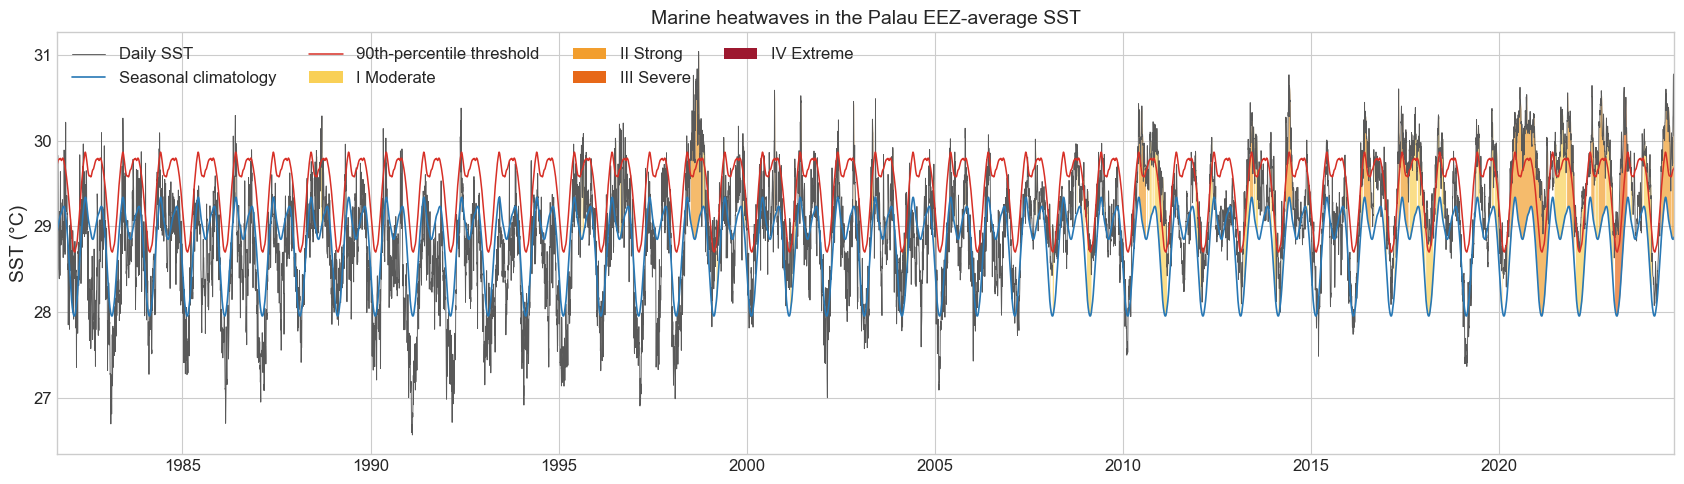

In [8]:
fig, ax = plot_mhw_timeline(series_eez, events_eez, clim_eez, "Marine heatwaves in the Palau EEZ-average SST")
fig.savefig(path_figs / "F_MHW_EEZ_full_period.png", dpi=300, bbox_inches="tight")
glue("mhw_eez_all", fig, display=False)

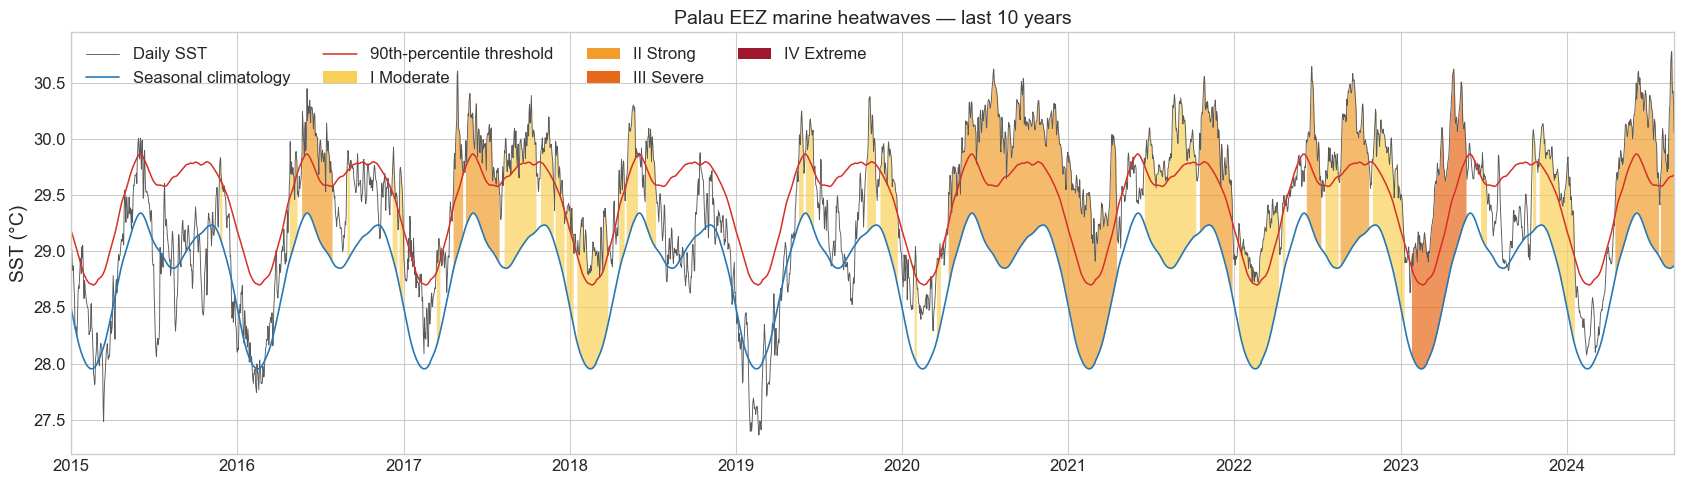

In [9]:
last_year = series_eez.index.max().year
fig, ax = plot_mhw_timeline(series_eez, events_eez, clim_eez, "Palau EEZ marine heatwaves — last 10 years",
                            f"{last_year - 9}-01-01", f"{last_year}-12-31")
fig.savefig(path_figs / "F_MHW_EEZ_last_10_years.png", dpi=300, bbox_inches="tight")

### EEZ annual indicators and trends

In [10]:
annual_eez, trend_eez = annual_indicators(t_eez, series_eez, events_eez, clim_eez)
trend_eez.round(2)

,indicator,mean,trend_per_decade,ci95_per_decade
0,Event count,2.24,1.09,0.37
1,MHW days,64.29,53.14,15.36
2,Mean duration,19.96,13.47,7.54
3,Mean maximum intensity,1.07,0.00,0.05
4,Cumulative intensity,18.74,12.90,8.27


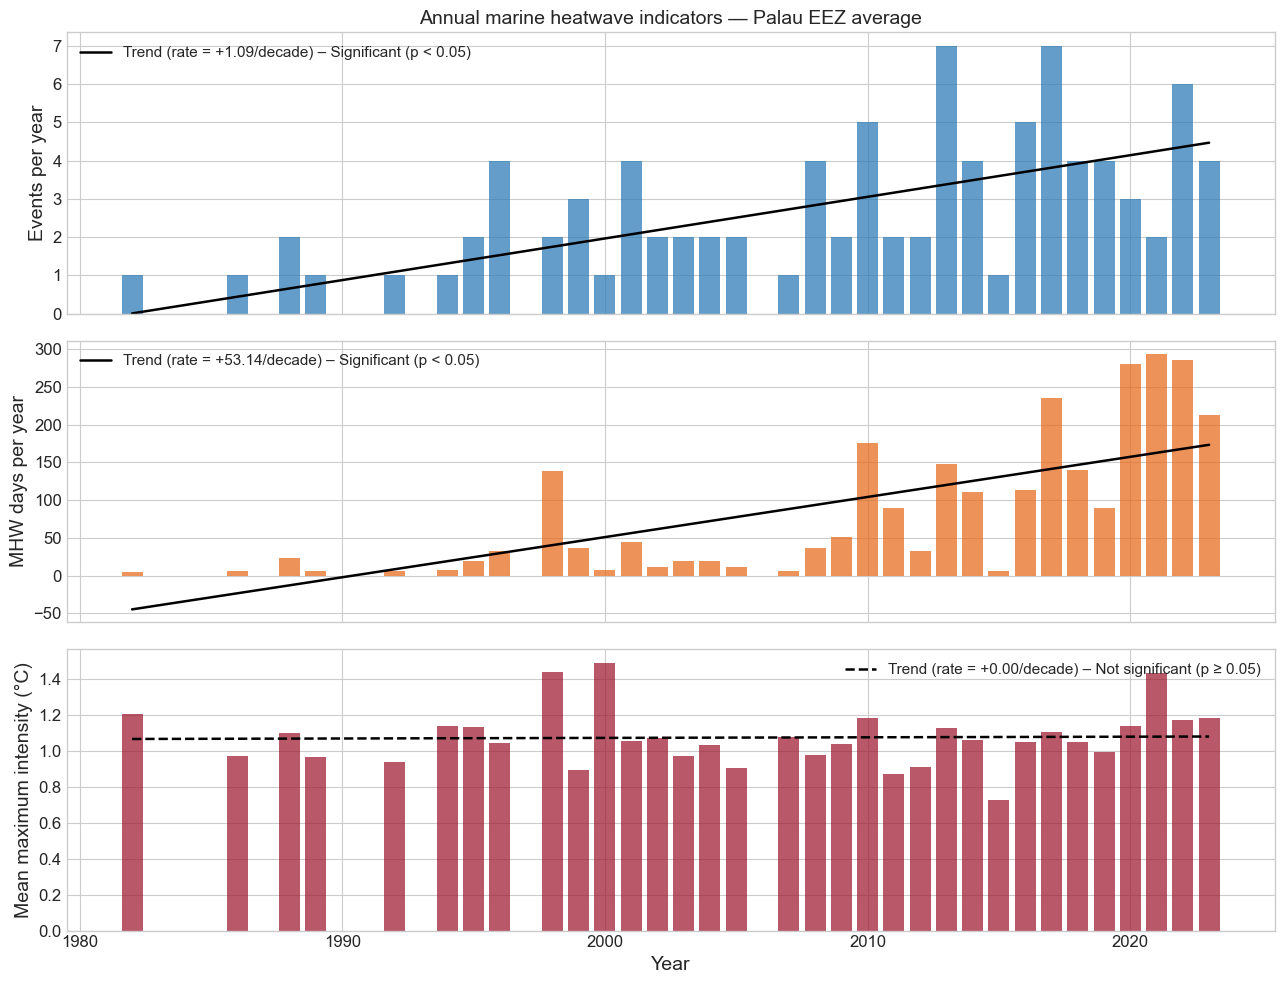

In [11]:
from scipy import stats

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
specs = [("event_count", "Events per year", "#2878b5"),
         ("mhw_days", "MHW days per year", "#e76818"),
         ("mean_max_intensity_degC", "Mean maximum intensity (°C)", "#9d182f")]
for ax, (column, ylabel, color) in zip(axes, specs):
    values = annual_eez[column]
    ax.bar(annual_eez.year, values, color=color, alpha=0.72)
    valid = values.notna()
    if valid.sum() >= 2:
        result = stats.linregress(annual_eez.loc[valid, "year"], values[valid])
        significant = result.pvalue < 0.05
        linestyle = "-" if significant else "--"
        status = "Significant (p < 0.05)" if significant else "Not significant (p ≥ 0.05)"
        ax.plot(
            annual_eez.loc[valid, "year"],
            result.intercept + result.slope * annual_eez.loc[valid, "year"],
            color="black", lw=1.8, linestyle=linestyle,
            label=f"Trend (rate = {result.slope * 10:+.2f}/decade) – {status}",
        )
        ax.legend(loc="best", fontsize=11)
    ax.set_ylabel(ylabel)
axes[-1].set_xlabel("Year")
axes[0].set_title("Annual marine heatwave indicators — Palau EEZ average")
fig.tight_layout()
fig.savefig(path_figs / "F_MHW_EEZ_annual_indicators.png", dpi=300, bbox_inches="tight")

### Most intense and longest EEZ-average events

In [12]:
display(event_table_eez.nlargest(10, "max_intensity_degC").round(2),
        event_table_eez.nlargest(10, "duration_days").round(2))

,start,end,peak,duration_days,max_intensity_degC,mean_intensity_degC,cumulative_intensity_degC_days,category
event,,,,,,,,
13,1998-07-01,1998-10-20,1998-09-21,112,1.98,1.21,135.75,Strong
95,2024-07-25,2024-08-24,2024-08-19,31,1.92,1.20,37.18,Strong
90,2023-01-25,2023-05-25,2023-04-28,121,1.67,1.15,139.59,Severe
81,2020-04-12,2021-04-17,2020-07-21,371,1.66,1.09,405.90,Strong
65,2017-04-20,2017-05-11,2017-04-30,22,1.63,0.98,21.66,Strong
88,2022-08-21,2022-10-23,2022-09-18,64,1.54,1.13,72.30,Strong
82,2021-06-17,2021-10-08,2021-08-22,114,1.53,0.93,105.83,Moderate
18,2000-09-22,2000-09-29,2000-09-27,8,1.49,1.07,8.59,Strong
42,2010-10-30,2011-02-27,2011-01-22,121,1.45,0.99,119.53,Moderate


,start,end,peak,duration_days,max_intensity_degC,mean_intensity_degC,cumulative_intensity_degC_days,category
event,,,,,,,,
81,2020-04-12,2021-04-17,2020-07-21,371,1.66,1.09,405.90,Strong
42,2010-10-30,2011-02-27,2011-01-22,121,1.45,0.99,119.53,Moderate
90,2023-01-25,2023-05-25,2023-04-28,121,1.67,1.15,139.59,Severe
82,2021-06-17,2021-10-08,2021-08-22,114,1.53,0.93,105.83,Moderate
13,1998-07-01,1998-10-20,1998-09-21,112,1.98,1.21,135.75,Strong
94,2024-04-16,2024-07-21,2024-07-02,97,1.30,0.98,95.18,Strong
84,2022-01-10,2022-04-08,2022-03-16,89,1.24,0.93,82.91,Moderate
93,2023-11-02,2024-01-18,2024-01-04,78,1.39,0.86,67.35,Moderate
66,2017-05-17,2017-07-30,2017-07-09,75,1.10,0.81,60.60,Strong


## 2. User-selected point analysis

Edit `user_lon` and `user_lat` in **Setup**, then rerun from Setup onward. The nearest OISST grid cell is used. The validation below reports whether the requested coordinate is inside the Palau EEZ and stops if the nearest cell has no ocean observations.

In [13]:
point_inside_eez = prepared_eez.covers(Point(user_lon, user_lat))
sst_point = ds["sst"].sel(lon=user_lon, lat=user_lat, method="nearest")
point_lon, point_lat = float(sst_point.lon), float(sst_point.lat)
if not bool(sst_point.notnull().any()):
    raise ValueError("The nearest grid cell contains no ocean SST. Choose another point.")

series_point = prepare_series(sst_point)
t_point, events_point, clim_point = detect_events(series_point)
event_table_point = event_dataframe(events_point)
annual_point, trend_point = annual_indicators(t_point, series_point, events_point, clim_point)

print(f"Requested coordinate inside Palau EEZ: {point_inside_eez}")
print(f"Nearest OISST cell: {point_lat:.3f}°N, {point_lon:.3f}°E")
print(f"Detected point events: {events_point['n_events']}")
event_table_point.tail(10)

Requested coordinate inside Palau EEZ: True
Nearest OISST cell: 7.375°N, 134.375°E
Detected point events: 135


,start,end,peak,duration_days,max_intensity_degC,mean_intensity_degC,cumulative_intensity_degC_days,category
event,,,,,,,,
125,2022-11-15,2022-12-13,2022-12-12,29,1.069381,0.819137,23.754975,Moderate
126,2022-12-19,2022-12-25,2022-12-25,7,0.964650,0.903580,6.325060,Moderate
127,2023-01-02,2023-01-06,2023-01-04,5,0.964782,0.923397,4.616984,Moderate
128,2023-02-16,2023-02-28,2023-02-22,13,1.016283,0.917818,11.931631,Moderate
129,2023-03-04,2023-05-22,2023-04-03,80,1.981296,1.314971,105.197711,Strong
130,2023-11-05,2023-11-22,2023-11-14,18,1.051932,0.792295,14.261315,Moderate
131,2023-12-28,2024-01-19,2024-01-16,23,1.491231,1.153906,26.539844,Moderate
132,2024-06-01,2024-07-17,2024-07-04,47,1.355614,1.143401,53.739846,Moderate
133,2024-07-29,2024-08-02,2024-07-31,5,1.534654,1.212350,6.061750,Moderate


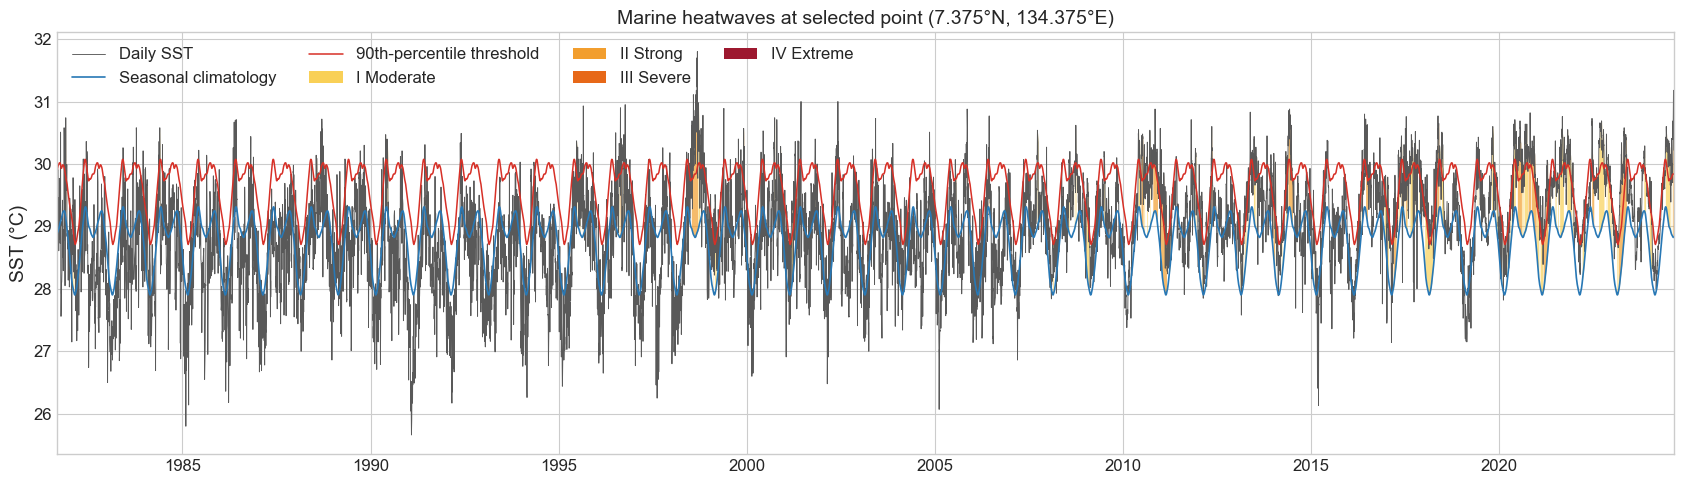

In [14]:
fig, ax = plot_mhw_timeline(
    series_point, events_point, clim_point,
    f"Marine heatwaves at selected point ({point_lat:.3f}°N, {point_lon:.3f}°E)")
fig.savefig(path_figs / "F_MHW_selected_point_full_period.png", dpi=300, bbox_inches="tight")

### EEZ–point comparison

In [15]:
comparison = trend_eez.merge(trend_point, on="indicator", suffixes=("_EEZ", "_point"))
comparison.round(2)

,indicator,mean_EEZ,trend_per_decade_EEZ,ci95_per_decade_EEZ,mean_point,trend_per_decade_point,ci95_per_decade_point
0,Event count,2.24,1.09,0.37,3.12,1.49,0.65
1,MHW days,64.29,53.14,15.36,44.12,32.06,10.50
2,Mean duration,19.96,13.47,7.54,10.79,3.66,1.88
3,Mean maximum intensity,1.07,0.00,0.05,1.38,-0.03,0.05
4,Cumulative intensity,18.74,12.90,8.27,12.55,3.74,2.58


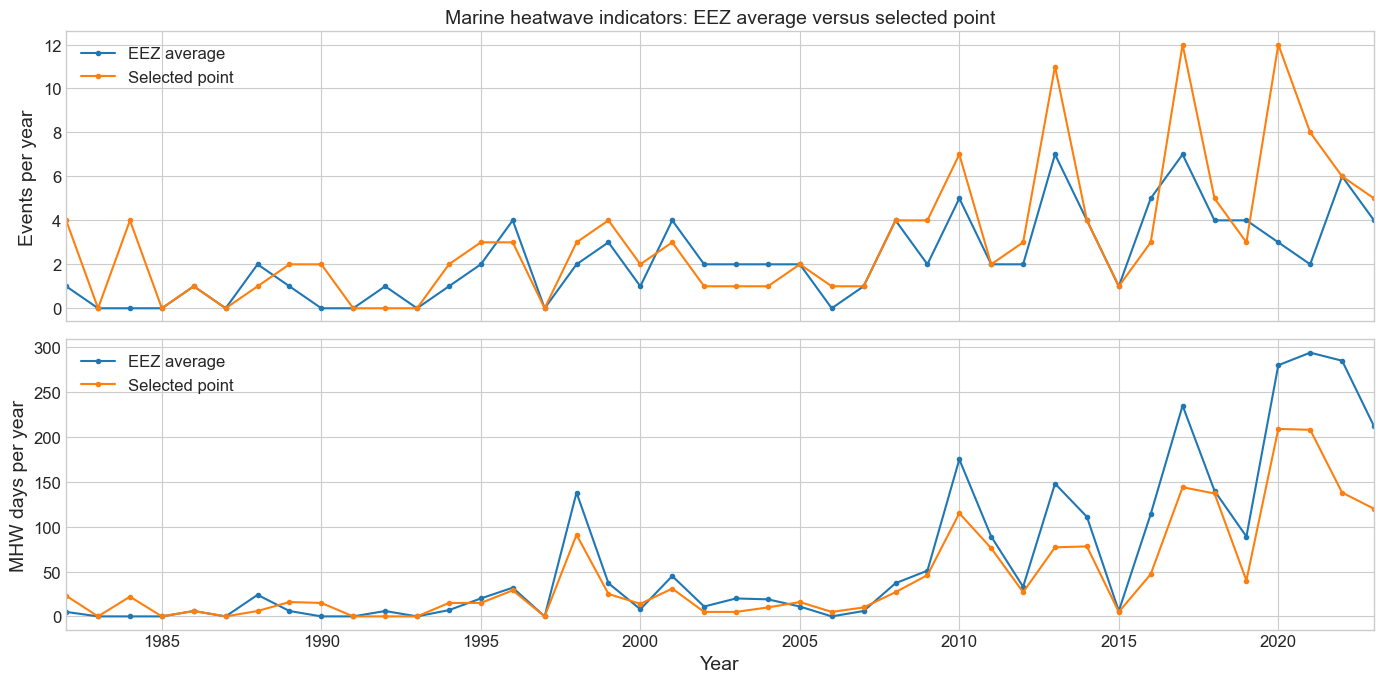

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, column, ylabel in zip(axes, ["event_count", "mhw_days"], ["Events per year", "MHW days per year"]):
    ax.plot(annual_eez.year, annual_eez[column], marker="o", ms=3, label="EEZ average")
    ax.plot(annual_point.year, annual_point[column], marker="o", ms=3, label="Selected point")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=LEGEND_FONTSIZE)
    ax.set_xlim(min(annual_eez.year.min(), annual_point.year.min()),
                max(annual_eez.year.max(), annual_point.year.max()))
axes[-1].set_xlabel("Year")
axes[0].set_title("Marine heatwave indicators: EEZ average versus selected point")
fig.tight_layout()
fig.savefig(path_figs / "F_MHW_EEZ_vs_point.png", dpi=300, bbox_inches="tight")

## Interpretation and reproducibility notes

- The EEZ result detects extremes in the **spatially averaged** SST series. It is deliberately conservative toward localized events and is not the same as computing MHWs independently in every grid cell and measuring affected area.
- The point result represents the nearest 0.25° OISST ocean grid cell, not an in-situ thermometer.
- The fixed 1983–2012 baseline makes changes through time comparable; changing it changes the threshold and detected events.
- In the trend tables, compare the absolute trend with `ci95_per_decade`; a trend is distinguishable from zero at approximately 95% confidence when its magnitude exceeds that interval.
- Reef exposure can differ from surface satellite SST because of depth, currents and local conditions.